# Signal-inference metrics

This notebook implements the metrics defined in
[`docs/signal_inference_metrics.md`](docs/signal_inference_metrics.md):

1. **M1 — diffusion fraction** (closed-form `E1` + Ridge regression `E2`,
   reported side-by-side).
2. **M2 — material amount on patient** (total detected rate, applicator-retained
   fraction with the `+y` central-z ROI as canonical, baseline-equivalent
   activity, time-window growth).
3. **M3 — secondary-source detection and location** (closed-form Mahalanobis
   χ² on the panel-asymmetry vector as primary detector, logistic-regression
   cross-check, positive-residual centroid for location).

Reading order: run **M3 first**; M1 and M2 are conditioned on M3's verdict so
that a localised secondary source does not get aliased into a fake diffusion
or a depleted applicator amount.

The notebook reuses the repetition-loading conventions from
`Detector_performance_analysis_Rn222_repetition_comparison.ipynb` and
`Detector_performance_analysis_Rn222_activity_normalized.ipynb`. Outputs are
saved alongside the existing analysis under
`outputs/Signal_inference_metrics/` and
`docs/figures/Signal_inference_metrics/`.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.interpolate import PchipInterpolator
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', None)

figure_output_dir = Path('docs') / 'figures' / 'Signal_inference_metrics'
figure_output_dir.mkdir(parents=True, exist_ok=True)
metrics_output_dir = Path('outputs') / 'Signal_inference_metrics'
metrics_output_dir.mkdir(parents=True, exist_ok=True)


def save_figure(fig, name):
    safe_name = ''.join(
        ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(name)
    ).strip('_')
    path = figure_output_dir / f'{safe_name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'Saved figure: {path}')
    return path


## Configuration

Case map, panel definitions, and z-binning are kept identical to the
companion repetition-comparison and activity-normalised notebooks so that
this analysis can be cross-checked against them. Only `volumeName`,
`(x_mm, y_mm, z_mm)`, `time_s`, `particleName == 'gamma'`, and
`boundary == 'enter'` are used as observables — the rest of the simulation
columns are unused by design.


In [2]:
repetition_run_dir = Path('rn222_repetition_runs') / 'rn222_2mmfully_10reps_10k'
generated_files_log = repetition_run_dir / 'generated_files_log.tsv'

analysis_cases = {
    'baseline': dict(label='No diffusion baseline',
                     diffusion_fraction=0.0, secondary_present=0,
                     secondary_fraction=0.0, secondary_z_mm=np.nan),
    'diff10':   dict(label='Source diffusion 10%',
                     diffusion_fraction=10.0, secondary_present=0,
                     secondary_fraction=0.0, secondary_z_mm=np.nan),
    'diff50':   dict(label='Source diffusion 50%',
                     diffusion_fraction=50.0, secondary_present=0,
                     secondary_fraction=0.0, secondary_z_mm=np.nan),
    'diff90':   dict(label='Source diffusion 90%',
                     diffusion_fraction=90.0, secondary_present=0,
                     secondary_fraction=0.0, secondary_z_mm=np.nan),
    'loc40':    dict(label='Localized secondary 40%',
                     diffusion_fraction=np.nan, secondary_present=1,
                     secondary_fraction=40.0, secondary_z_mm=500.0),
    'loc60':    dict(label='Localized secondary 60%',
                     diffusion_fraction=np.nan, secondary_present=1,
                     secondary_fraction=60.0, secondary_z_mm=500.0),
}

case_order = ['baseline', 'diff10', 'diff50', 'diff90', 'loc40', 'loc60']
case_labels = {key: meta['label'] for key, meta in analysis_cases.items()}
diffusion_training_cases = ['baseline', 'diff10', 'diff50', 'diff90']
secondary_training_cases = case_order

panel_sets = {
    'PosY': ['physPhotonDetectorPosY'],
    'NegY': ['physPhotonDetectorNegY'],
    'PosX': ['physPhotonDetectorPosX'],
    'NegX': ['physPhotonDetectorNegX'],
    'PosZ': ['physPhotonDetectorPosZ'],
    'NegZ': ['physPhotonDetectorNegZ'],
    'Ysum': ['physPhotonDetectorPosY', 'physPhotonDetectorNegY'],
    'Xsum': ['physPhotonDetectorPosX', 'physPhotonDetectorNegX'],
    'Zsum': ['physPhotonDetectorPosZ', 'physPhotonDetectorNegZ'],
    'Sides': ['physPhotonDetectorPosY', 'physPhotonDetectorNegY',
              'physPhotonDetectorPosX', 'physPhotonDetectorNegX'],
    'All': ['physPhotonDetectorPosY', 'physPhotonDetectorNegY',
            'physPhotonDetectorPosX', 'physPhotonDetectorNegX',
            'physPhotonDetectorPosZ', 'physPhotonDetectorNegZ'],
}
all_detector_panels = panel_sets['All']
side_panels = panel_sets['Sides']
z_panels = panel_sets['Zsum']

z_bins = np.linspace(-1500, 1500, 61)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
central_z_roi_mm = (-150.0, 150.0)
secondary_search_z_roi_mm = (250.0, 750.0)

reference_activity_uCi = 3.0
time_windows_s = {
    '2h':     2 * 3600.0,
    '12h':    12 * 3600.0,
    '1d':     24 * 3600.0,
    '2d':     2 * 24 * 3600.0,
    '5d':     5 * 24 * 3600.0,
    '1e6s':   1.0e6,
}
default_time_cut_s = time_windows_s['1e6s']


## Repetition loading

The manifest stores absolute simulation paths from the machine where the
campaign was generated. The resolver below first tries the original absolute
path and, if missing, falls back to resolving the same stem under
`rn222_repetition_runs/.../outputs/` relative to the project root. This keeps
the notebook portable between the user's machine and a sandbox copy of the
repository.


In [3]:
USE_COLS = [
    'eventID', 'particleName', 'boundary', 'volumeName',
    'x_mm', 'y_mm', 'z_mm', 'time_s', 'kineticEnergy_MeV',
]


def _resolve_output_stem(stem):
    s = str(stem)
    candidate = Path(s + '_photon_boundaries.csv')
    if candidate.exists():
        return candidate
    idx = s.find('rn222_repetition_runs')
    if idx >= 0:
        rel = Path(s[idx:] + '_photon_boundaries.csv')
        if rel.exists():
            return rel
    return candidate  # may not exist; caller logs


def load_repetition(path, case_key, rep):
    df = pd.read_csv(path, usecols=USE_COLS)
    entries = df[
        (df['particleName'] == 'gamma')
        & (df['boundary'] == 'enter')
        & (df['volumeName'].isin(all_detector_panels))
    ].copy()
    return {
        'case': case_key,
        'rep': int(rep),
        'path': str(path),
        'entries': entries,
        'n_events': int(df['eventID'].nunique()),
    }


def load_all_repetitions():
    log_df = pd.read_csv(generated_files_log, sep='\t')
    reps_by_case = {key: [] for key in analysis_cases}
    skipped = []
    for row in log_df.itertuples(index=False):
        if row.case not in reps_by_case:
            continue
        csv_path = _resolve_output_stem(row.output_stem)
        if not csv_path.exists():
            skipped.append({'case': row.case, 'rep': row.rep,
                            'expected_csv': str(csv_path)})
            continue
        reps_by_case[row.case].append(load_repetition(csv_path, row.case, row.rep))
    reps_by_case = {key: reps for key, reps in reps_by_case.items() if reps}
    return reps_by_case, pd.DataFrame(skipped)


cases, skipped_repetitions_df = load_all_repetitions()
print('Loaded repetitions:')
for key in case_order:
    if key not in cases:
        print(f'  {key:8s}: 0 reps')
        continue
    reps = cases[key]
    rep_ids = [r['rep'] for r in reps]
    n_entries = sum(len(r['entries']) for r in reps)
    print(f"  {key:8s}: {len(reps):2d} reps {rep_ids}, "
          f"{n_entries} total detector entries")
if not skipped_repetitions_df.empty:
    print(f'\nSkipped {len(skipped_repetitions_df)} missing outputs:')
    display(skipped_repetitions_df.head(10))
if 'baseline' not in cases:
    raise RuntimeError('No baseline repetitions are available; cannot proceed.')


Loaded repetitions:
  baseline: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 125003 total detector entries
  diff10  : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 124312 total detector entries
  diff50  : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 122998 total detector entries
  diff90  : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 120570 total detector entries
  loc40   : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 121736 total detector entries
  loc60   : 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 121343 total detector entries


## Feature extraction

Each repetition is reduced to a single feature row containing:

- **Panel counts and rates** for the 6 individual panels and the
  `Ysum`/`Xsum`/`Zsum`/`Sides` aggregates.
- **Panel-asymmetry vector** `(A_x, A_y, A_z)` and forward-fraction
  `F_{+y}`.
- **Longitudinal profile moments** (`σ_z`, Q10/Q50/Q90, Q10–Q90 width) on
  `Ysum`, `Xsum`, and `Sides`.
- **Central-z forward fraction** `C_{+y}` and central-ROI rates per view.
- **Baseline-subtracted residual summaries** (L1 norm, positive-residual
  total, positive-residual centroid in z, positive-residual peak position
  and height) per view.
- **Per-time-window detector-rate snapshots** for `R_{tot}` and `R_{app}^{+y}`
  at the configured time windows.

The baseline mean profiles are computed once from the baseline repetitions
and reused throughout.


In [4]:
def select_entries(rep, panels, time_limit_s=None):
    selected = rep['entries'][rep['entries']['volumeName'].isin(panels)]
    if time_limit_s is not None:
        selected = selected[
            selected['time_s'].notna() & (selected['time_s'] <= time_limit_s)
        ]
    return selected


def hist_counts(rep, panels, bins=z_bins, coord='z_mm', time_limit_s=None):
    selected = select_entries(rep, panels, time_limit_s=time_limit_s)
    if selected.empty:
        return np.zeros(len(bins) - 1, dtype=float)
    return np.histogram(selected[coord], bins=bins)[0].astype(float)


def baseline_mean_profiles(cases_, bins=z_bins, time_limit_s=default_time_cut_s):
    profiles = {}
    for view_name, panels in panel_sets.items():
        counts = np.vstack([
            hist_counts(rep, panels, bins=bins, time_limit_s=time_limit_s) / rep['n_events']
            for rep in cases_['baseline']
        ])
        profiles[view_name] = counts.mean(axis=0)
    return profiles


baseline_profiles = baseline_mean_profiles(cases)


def weighted_mean_std(values, weights):
    weights = np.asarray(weights, dtype=float)
    values = np.asarray(values, dtype=float)
    total = weights.sum()
    if total <= 0:
        return np.nan, np.nan
    mean = float(np.sum(values * weights) / total)
    var = float(np.sum(weights * (values - mean) ** 2) / total)
    return mean, float(np.sqrt(max(var, 0.0)))


def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if weights.sum() <= 0:
        return [np.nan for _ in quantiles]
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cdf = np.cumsum(weights) / weights.sum()
    return list(np.interp(quantiles, cdf, values))


def positive_residual_centroid(centers, residual):
    positive = np.clip(np.asarray(residual, dtype=float), 0, None)
    total = positive.sum()
    if total <= 0:
        return np.nan
    return float(np.sum(np.asarray(centers) * positive) / total)


def positive_residual_peak(centers, residual):
    positive = np.clip(np.asarray(residual, dtype=float), 0, None)
    if positive.sum() <= 0:
        return np.nan, 0.0
    idx = int(np.argmax(positive))
    return float(centers[idx]), float(positive[idx])


def time_window_rate(rep, panels, time_limit_s, z_roi=None):
    selected = select_entries(rep, panels, time_limit_s=time_limit_s)
    if z_roi is not None:
        lo, hi = z_roi
        selected = selected[(selected['z_mm'] >= lo) & (selected['z_mm'] <= hi)]
    return len(selected) / rep['n_events']


def extract_features_for_rep(rep, baseline_profiles, time_limit_s=default_time_cut_s):
    meta = analysis_cases[rep['case']]
    row = {
        'case': rep['case'],
        'rep': rep['rep'],
        'label': case_labels[rep['case']],
        'n_events': rep['n_events'],
        'time_cut_s': time_limit_s,
        'diffusion_fraction_true': meta['diffusion_fraction'],
        'secondary_present_true': meta['secondary_present'],
        'secondary_fraction_true': meta['secondary_fraction'],
        'secondary_z_mm_true': meta['secondary_z_mm'],
    }

    side_rate = len(select_entries(rep, side_panels, time_limit_s)) / rep['n_events']
    row['side_rate_per_event'] = side_rate
    row['total_rate_per_event'] = (
        len(select_entries(rep, all_detector_panels, time_limit_s)) / rep['n_events']
    )

    panel_counts = {
        p: len(select_entries(rep, [v], time_limit_s))
        for p, v in [('+x', 'physPhotonDetectorPosX'),
                     ('-x', 'physPhotonDetectorNegX'),
                     ('+y', 'physPhotonDetectorPosY'),
                     ('-y', 'physPhotonDetectorNegY'),
                     ('+z', 'physPhotonDetectorPosZ'),
                     ('-z', 'physPhotonDetectorNegZ')]
    }
    for tag, val in panel_counts.items():
        row[f'N_{tag}'] = val

    def asym(plus, minus):
        s = plus + minus
        return (plus - minus) / s if s > 0 else np.nan

    row['A_x'] = asym(panel_counts['+x'], panel_counts['-x'])
    row['A_y'] = asym(panel_counts['+y'], panel_counts['-y'])
    row['A_z'] = asym(panel_counts['+z'], panel_counts['-z'])
    row['F_posy'] = (
        panel_counts['+y']
        / (panel_counts['+y'] + panel_counts['-y']
           + panel_counts['+x'] + panel_counts['-x'])
        if side_rate > 0 else np.nan
    )

    for view_name, panels in panel_sets.items():
        counts = hist_counts(rep, panels, time_limit_s=time_limit_s)
        rate_profile = counts / rep['n_events']
        total_counts = counts.sum()
        total_rate = total_counts / rep['n_events']

        mean_z, std_z = weighted_mean_std(z_centers, counts)
        q10, q50, q90 = weighted_quantile(z_centers, counts, [0.10, 0.50, 0.90])
        central_mask = (z_centers >= central_z_roi_mm[0]) & (z_centers <= central_z_roi_mm[1])
        secondary_mask = (
            (z_centers >= secondary_search_z_roi_mm[0])
            & (z_centers <= secondary_search_z_roi_mm[1])
        )
        residual = rate_profile - baseline_profiles[view_name]
        peak_z, peak_amp = positive_residual_peak(z_centers, residual)

        prefix = f'{view_name}_'
        row[prefix + 'counts'] = total_counts
        row[prefix + 'rate_per_event'] = total_rate
        row[prefix + 'z_mean_mm'] = mean_z
        row[prefix + 'z_std_mm'] = std_z
        row[prefix + 'z_q10_mm'] = q10
        row[prefix + 'z_median_mm'] = q50
        row[prefix + 'z_q90_mm'] = q90
        row[prefix + 'z_q80_width_mm'] = (
            q90 - q10 if np.isfinite(q90) and np.isfinite(q10) else np.nan
        )
        row[prefix + 'central_rate_per_event'] = counts[central_mask].sum() / rep['n_events']
        row[prefix + 'central_fraction'] = (
            counts[central_mask].sum() / total_counts if total_counts > 0 else np.nan
        )
        row[prefix + 'secondary_roi_rate_per_event'] = (
            counts[secondary_mask].sum() / rep['n_events']
        )
        row[prefix + 'residual_l1_per_event'] = float(np.abs(residual).sum())
        row[prefix + 'positive_residual_per_event'] = float(np.clip(residual, 0, None).sum())
        row[prefix + 'positive_residual_centroid_z_mm'] = positive_residual_centroid(z_centers, residual)
        row[prefix + 'positive_residual_peak_z_mm'] = peak_z
        row[prefix + 'positive_residual_peak_per_event'] = peak_amp

    # +y central-ROI rate (canonical M2 applicator-retained observable)
    row['posy_central_rate_per_event'] = time_window_rate(
        rep, ['physPhotonDetectorPosY'], time_limit_s, z_roi=central_z_roi_mm
    )

    # Time-window growth snapshots (computed alongside default cut)
    for tw_name, tw_s in time_windows_s.items():
        row[f'tw_{tw_name}_total_rate'] = time_window_rate(
            rep, all_detector_panels, tw_s
        )
        row[f'tw_{tw_name}_posy_central_rate'] = time_window_rate(
            rep, ['physPhotonDetectorPosY'], tw_s, z_roi=central_z_roi_mm
        )

    return row


features_rows = []
for case_key in case_order:
    if case_key not in cases:
        continue
    for rep in cases[case_key]:
        features_rows.append(extract_features_for_rep(rep, baseline_profiles))
features_df = pd.DataFrame(features_rows).sort_values(['case', 'rep']).reset_index(drop=True)

features_df.to_csv(metrics_output_dir / 'detector_signal_features.csv', index=False)
print(f'Features extracted: {features_df.shape[0]} repetitions × {features_df.shape[1]} columns')
display(
    features_df.groupby('case', sort=False)[
        ['total_rate_per_event', 'A_x', 'A_y', 'A_z',
         'F_posy', 'Ysum_z_std_mm', 'posy_central_rate_per_event']
    ].mean().reindex(case_order)
)


Features extracted: 60 repetitions × 210 columns


,total_rate_per_event,A_x,A_y,A_z,F_posy,Ysum_z_std_mm,posy_central_rate_per_event
case,,,,,,,
baseline,1.278984,0.003599,0.618453,-0.063460,0.474202,233.840418,0.343563
diff10,1.280268,0.001793,0.570687,0.070071,0.451681,254.573525,0.313620
diff50,1.306134,0.001986,0.351647,-0.025783,0.367530,326.375475,0.213988
diff90,1.307713,-0.002099,0.075846,-0.000895,0.274036,399.513000,0.098738
loc40,1.302328,-0.000018,0.402366,0.856552,0.387562,310.091611,0.219913
loc60,1.321903,0.005964,0.281826,0.917387,0.345887,313.623311,0.161742


## M1 — Diffusion fraction

Two estimators reported side-by-side, per the design document
[`docs/signal_inference_metrics.md`](docs/signal_inference_metrics.md) §2.3:

- **E1 (closed-form).** Monotone calibration of the true diffusion fraction
  against three single-variable observables: y-panel asymmetry `A_y`,
  longitudinal profile width `σ_z^{Ysum}`, and central forward fraction
  `C_{+y}`. The notebook fits each with a PCHIP monotone interpolator over
  the four calibration points `{baseline, diff10, diff50, diff90}` and
  combines the three observables via inverse-variance weighting on
  leave-one-rep-out residuals.
- **E2 (Ridge).** Multivariate `RidgeCV` on the full shape feature set, with
  leave-one-rep-out cross-validation. Same feature stack as the earlier
  notebook.

`loc40` and `loc60` are excluded from the training set (they correspond to a
different physical hypothesis). The diffusion estimate is *only* reportable
once M3 has cleared the secondary-source hypothesis.


,case,diffusion_fraction,A_y,Ysum_z_std_mm,PosY_central_fraction
0,baseline,0.0,0.618453,233.840418,0.567977
1,diff10,10.0,0.570687,254.573525,0.545675
2,diff50,50.0,0.351647,326.375475,0.455439
3,diff90,90.0,0.075846,399.513000,0.285713


E1 (closed-form) per-observable metrics:


,MAE_pp,R2
A_y,1.681599,0.996353
sigma_z_Ysum,0.935731,0.998348
C_posy,1.614509,0.995192
combined,1.110537,0.998363


E2 uses 34 shape features.
E2 (Ridge LOO) metrics: {'MAE_pp': 0.9750369622433777, 'R2': 0.9985432036256536}


,case,true,E1_Ay,E1_sigma_z,E1_Cposy,E1_combined,E2_ridge,E2_ridge_sd
0,baseline,0.0,0.926435,0.447657,1.182235,0.852109,0.495403,0.741095
1,diff10,10.0,9.974632,10.010447,10.031192,10.005424,10.185422,1.512436
2,diff50,50.0,49.974746,49.993370,49.910489,49.959535,49.982338,1.442270
3,diff90,90.0,89.983850,89.999684,89.945201,89.976245,89.700263,1.684824


Saved figure: docs/figures/Signal_inference_metrics/M1_diffusion_E1_vs_E2.png


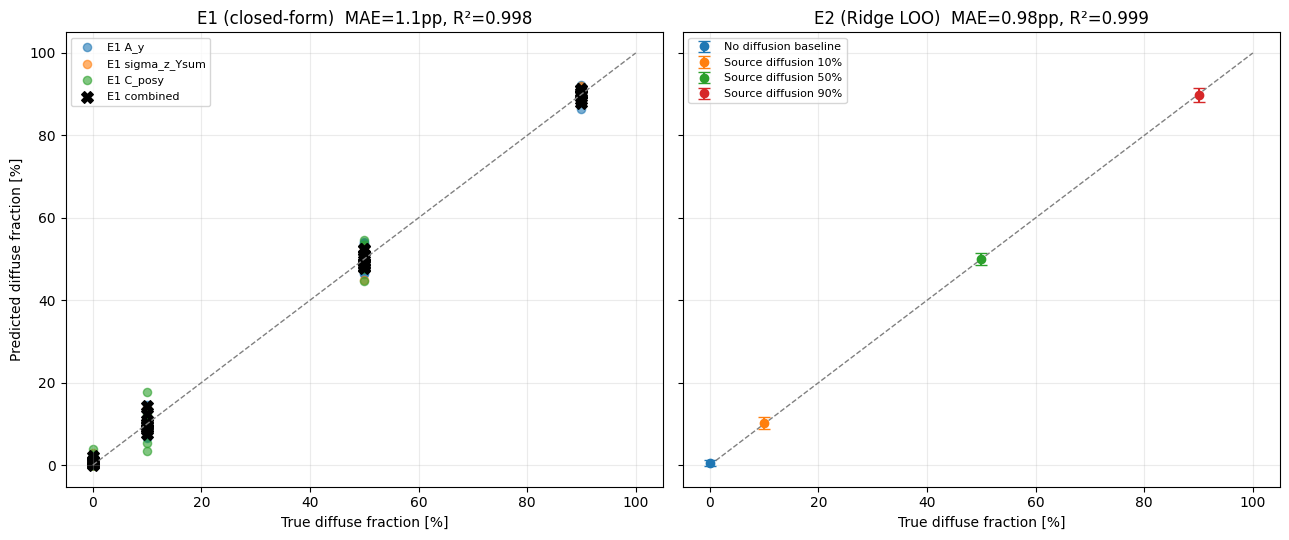

In [5]:
diff_train_df = features_df[features_df['case'].isin(diffusion_training_cases)].copy()
true_diff = diff_train_df['diffusion_fraction_true'].to_numpy(dtype=float)

# --- E1: closed-form PCHIP calibrations on three single-variable observables ---

m1_observables = {
    'A_y':            ('A_y',                  False),    # monotone decreasing
    'sigma_z_Ysum':   ('Ysum_z_std_mm',        True),     # monotone increasing
    'C_posy':         ('PosY_central_fraction', False),   # monotone decreasing
}

calibration_points = (
    diff_train_df.groupby('case', sort=False)
    .agg(diffusion_fraction=('diffusion_fraction_true', 'first'),
         A_y=('A_y', 'mean'),
         Ysum_z_std_mm=('Ysum_z_std_mm', 'mean'),
         PosY_central_fraction=('PosY_central_fraction', 'mean'))
    .reindex(diffusion_training_cases)
    .reset_index()
)

display(calibration_points)


def fit_pchip(x, y, x_increasing):
    """Fit a monotone PCHIP from x → y; orient x so it's increasing."""
    order = np.argsort(x) if x_increasing else np.argsort(x)[::-1]
    return PchipInterpolator(x[order], y[order])


pchip_fits = {}
for name, (col, _increasing) in m1_observables.items():
    x = calibration_points[col].to_numpy(dtype=float)
    y = calibration_points['diffusion_fraction'].to_numpy(dtype=float)
    order = np.argsort(x)
    pchip_fits[name] = PchipInterpolator(x[order], y[order], extrapolate=True)


def e1_predict(features_row, fit_name=None):
    """Predict diffusion fraction from each observable; return per-fit + combined."""
    preds = {}
    for name, (col, _) in m1_observables.items():
        val = float(features_row[col])
        preds[name] = float(np.clip(pchip_fits[name](val), 0, 100))
    if fit_name is not None:
        return preds[fit_name]
    # Equal-weight combination across the three observables
    preds['combined'] = float(np.mean([preds[n] for n in m1_observables]))
    return preds


e1_per_rep = []
for _, row in diff_train_df.iterrows():
    preds = e1_predict(row)
    preds.update({'case': row['case'], 'rep': row['rep'],
                  'true_diffusion_fraction': row['diffusion_fraction_true']})
    e1_per_rep.append(preds)
e1_per_rep_df = pd.DataFrame(e1_per_rep)

e1_per_obs_metrics = {}
for obs in list(m1_observables.keys()) + ['combined']:
    e1_per_obs_metrics[obs] = {
        'MAE_pp': float(mean_absolute_error(e1_per_rep_df['true_diffusion_fraction'],
                                            e1_per_rep_df[obs])),
        'R2': float(r2_score(e1_per_rep_df['true_diffusion_fraction'],
                             e1_per_rep_df[obs])),
    }
e1_metrics_df = pd.DataFrame(e1_per_obs_metrics).T
print('E1 (closed-form) per-observable metrics:')
display(e1_metrics_df)

# --- E2: multivariate Ridge regression with LOO ---

def columns_matching(df, prefixes=(), endings=()):
    cols = []
    for col in df.columns:
        if prefixes and not any(col.startswith(p) for p in prefixes):
            continue
        if endings and not any(col.endswith(e) for e in endings):
            continue
        cols.append(col)
    return cols


shape_feature_cols = sorted(set(
    columns_matching(
        features_df,
        prefixes=('PosY_', 'NegY_', 'Ysum_', 'Xsum_', 'Sides_'),
        endings=('z_std_mm', 'z_q80_width_mm', 'central_fraction',
                 'positive_residual_centroid_z_mm',
                 'positive_residual_peak_z_mm', 'residual_l1_per_event'),
    )
    + ['A_x', 'A_y', 'A_z', 'F_posy']
))
print(f'E2 uses {len(shape_feature_cols)} shape features.')

X_e2 = diff_train_df[shape_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

loo = LeaveOneOut()
e2_pred = np.zeros(len(diff_train_df))
for train_idx, test_idx in loo.split(X_e2):
    model = make_pipeline(StandardScaler(),
                          RidgeCV(alphas=np.logspace(-4, 4, 25)))
    model.fit(X_e2.iloc[train_idx], true_diff[train_idx])
    e2_pred[test_idx] = model.predict(X_e2.iloc[test_idx])

e2_model_full = make_pipeline(StandardScaler(),
                              RidgeCV(alphas=np.logspace(-4, 4, 25)))
e2_model_full.fit(X_e2, true_diff)

e2_metrics = {
    'MAE_pp': float(mean_absolute_error(true_diff, e2_pred)),
    'R2': float(r2_score(true_diff, e2_pred)),
}
print('E2 (Ridge LOO) metrics:', e2_metrics)

# --- Combine E1 + E2 into one per-rep prediction table ---

diff_predictions = diff_train_df[['case', 'rep', 'diffusion_fraction_true']].copy()
diff_predictions = diff_predictions.merge(
    e1_per_rep_df.drop(columns=['true_diffusion_fraction']), on=['case', 'rep'])
diff_predictions['E2_ridge'] = np.clip(e2_pred, 0, 100)
diff_predictions.to_csv(metrics_output_dir / 'diffusion_predictions_E1_E2.csv', index=False)

diff_summary = (
    diff_predictions.groupby('case', sort=False)
    .agg(true=('diffusion_fraction_true', 'first'),
         E1_Ay=('A_y', 'mean'),
         E1_sigma_z=('sigma_z_Ysum', 'mean'),
         E1_Cposy=('C_posy', 'mean'),
         E1_combined=('combined', 'mean'),
         E2_ridge=('E2_ridge', 'mean'),
         E2_ridge_sd=('E2_ridge', 'std'))
    .reindex(diffusion_training_cases).reset_index()
)
display(diff_summary)
diff_summary.to_csv(metrics_output_dir / 'diffusion_summary.csv', index=False)

# --- E1 vs E2 plot ---

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
ax = axes[0]
for obs, (col, _) in m1_observables.items():
    ax.scatter(diff_predictions['diffusion_fraction_true'],
               diff_predictions[obs], s=35, alpha=0.6, label=f'E1 {obs}')
ax.scatter(diff_predictions['diffusion_fraction_true'],
           diff_predictions['combined'], s=70, marker='X', color='black',
           label='E1 combined')
ax.plot([0, 100], [0, 100], color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('True diffuse fraction [%]')
ax.set_ylabel('Predicted diffuse fraction [%]')
ax.set_title(f'E1 (closed-form)  '
             f'MAE={e1_per_obs_metrics["combined"]["MAE_pp"]:.1f}pp, '
             f'R²={e1_per_obs_metrics["combined"]["R2"]:.3f}')
ax.grid(alpha=0.25); ax.legend(fontsize=8)

ax = axes[1]
for case_key, group in diff_predictions.groupby('case'):
    ax.errorbar(group['diffusion_fraction_true'].iloc[0],
                group['E2_ridge'].mean(), yerr=group['E2_ridge'].std(),
                fmt='o', capsize=4, label=case_labels[case_key])
ax.plot([0, 100], [0, 100], color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('True diffuse fraction [%]')
ax.set_title(f'E2 (Ridge LOO)  MAE={e2_metrics["MAE_pp"]:.2f}pp, '
             f'R²={e2_metrics["R2"]:.3f}')
ax.grid(alpha=0.25); ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'M1_diffusion_E1_vs_E2')
plt.show()


## M2 — Material/signal amount on patient

- **Total amount.** `R_{tot}` = total detected gamma entries per primary
  decay. Converted to baseline-equivalent activity at the 3 µCi DaRT
  reference.
- **Applicator-retained amount (canonical).** `R_{app}^{+y}` = `+y` panel
  rate within `|z| ≤ 150 mm`. Normalised by baseline →
  `\hat f_{app} = R_{app}^{+y} / R_{app}^{+y,B}` measures how much activity
  remains on the applicator.
- **Cross-check.** All-side-panel central-ROI fraction
  (`Sides_central_rate_per_event`), kept for comparison with the previous
  notebook.
- **Time-window growth.** `R_{tot}` and `\hat f_{app}` reported at
  `T ∈ {2 h, 12 h, 1 d, 2 d, 5 d, 10⁶ s}`.


,case,label,R_tot_per_event,R_tot_per_event_sd,R_tot_over_baseline,R_tot_over_baseline_sd,baseline_equivalent_activity_uCi,baseline_equivalent_activity_uCi_sd,f_app_posy,f_app_posy_sd,f_app_sides_xcheck,f_app_sides_xcheck_sd
0,baseline,No diffusion baseline,1.278984,0.005760,1.000000,0.004503,3.000000,0.013510,1.000000,0.012790,1.000000,0.009900
1,diff10,Source diffusion 10%,1.280268,0.006977,1.001004,0.005455,3.003012,0.016365,0.912845,0.014284,0.941694,0.008754
2,diff50,Source diffusion 50%,1.306134,0.013818,1.021228,0.010804,3.063685,0.032412,0.622848,0.016323,0.723670,0.014043
3,diff90,Source diffusion 90%,1.307713,0.005527,1.022463,0.004322,3.067389,0.012965,0.287395,0.011445,0.466955,0.009854
4,loc40,Localized secondary 40%,1.302328,0.011258,1.018252,0.008802,3.054757,0.026407,0.640093,0.025373,0.666257,0.014640
5,loc60,Localized secondary 60%,1.321903,0.008843,1.033557,0.006914,3.100672,0.020743,0.470779,0.011695,0.506054,0.010013


Saved figure: docs/figures/Signal_inference_metrics/M2_amount_total_and_applicator.png


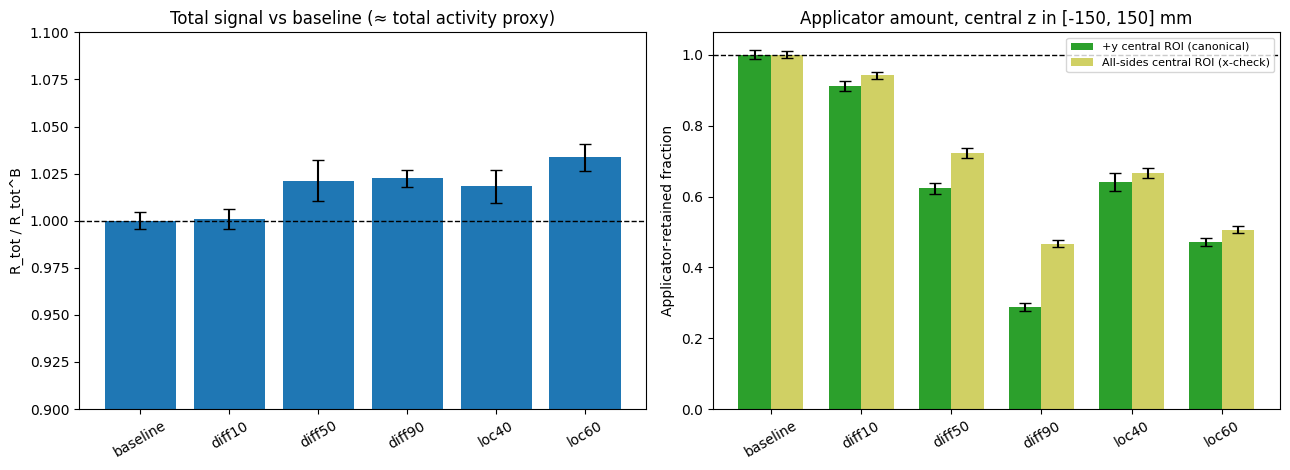

Saved figure: docs/figures/Signal_inference_metrics/M2_amount_time_window_growth.png


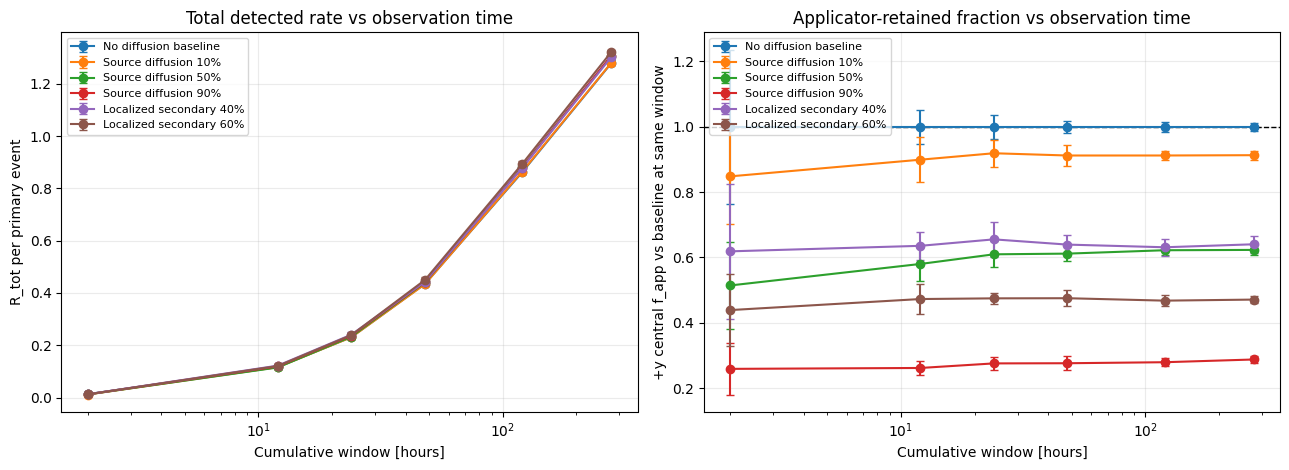

In [6]:
baseline_total_rate_mean = features_df.loc[features_df['case'] == 'baseline',
                                           'total_rate_per_event'].mean()
baseline_posy_central_rate_mean = features_df.loc[features_df['case'] == 'baseline',
                                                  'posy_central_rate_per_event'].mean()
baseline_sides_central_rate_mean = features_df.loc[features_df['case'] == 'baseline',
                                                   'Sides_central_rate_per_event'].mean()

amount_df = features_df[['case', 'rep', 'label',
                         'total_rate_per_event', 'posy_central_rate_per_event',
                         'Sides_central_rate_per_event']].copy()
amount_df['R_tot_over_baseline'] = (
    amount_df['total_rate_per_event'] / baseline_total_rate_mean
)
amount_df['baseline_equivalent_activity_uCi'] = (
    amount_df['R_tot_over_baseline'] * reference_activity_uCi
)
amount_df['f_app_posy'] = (
    amount_df['posy_central_rate_per_event'] / baseline_posy_central_rate_mean
)
amount_df['f_app_sides_xcheck'] = (
    amount_df['Sides_central_rate_per_event'] / baseline_sides_central_rate_mean
)

amount_summary = (
    amount_df.groupby('case', sort=False)
    .agg(label=('label', 'first'),
         R_tot_per_event=('total_rate_per_event', 'mean'),
         R_tot_per_event_sd=('total_rate_per_event', 'std'),
         R_tot_over_baseline=('R_tot_over_baseline', 'mean'),
         R_tot_over_baseline_sd=('R_tot_over_baseline', 'std'),
         baseline_equivalent_activity_uCi=('baseline_equivalent_activity_uCi', 'mean'),
         baseline_equivalent_activity_uCi_sd=('baseline_equivalent_activity_uCi', 'std'),
         f_app_posy=('f_app_posy', 'mean'),
         f_app_posy_sd=('f_app_posy', 'std'),
         f_app_sides_xcheck=('f_app_sides_xcheck', 'mean'),
         f_app_sides_xcheck_sd=('f_app_sides_xcheck', 'std'))
    .reindex(case_order).reset_index()
)

display(amount_summary)
amount_df.to_csv(metrics_output_dir / 'amount_by_repetition.csv', index=False)
amount_summary.to_csv(metrics_output_dir / 'amount_summary.csv', index=False)

# --- Plot: total amount vs applicator-retained amount ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
y = amount_summary['R_tot_over_baseline']
yerr = amount_summary['R_tot_over_baseline_sd']
ax.bar(amount_summary['case'], y, yerr=yerr, capsize=4, color='tab:blue')
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_ylim(0.9, 1.1)
ax.set_ylabel('R_tot / R_tot^B')
ax.set_title('Total signal vs baseline (≈ total activity proxy)')
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
posy = amount_summary['f_app_posy']; posy_err = amount_summary['f_app_posy_sd']
sides = amount_summary['f_app_sides_xcheck']; sides_err = amount_summary['f_app_sides_xcheck_sd']
xpos = np.arange(len(amount_summary))
ax.bar(xpos - 0.18, posy, width=0.36, yerr=posy_err, capsize=4,
       label='+y central ROI (canonical)', color='tab:green')
ax.bar(xpos + 0.18, sides, width=0.36, yerr=sides_err, capsize=4,
       label='All-sides central ROI (x-check)', color='tab:olive', alpha=0.7)
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_xticks(xpos); ax.set_xticklabels(amount_summary['case'], rotation=30)
ax.set_ylabel('Applicator-retained fraction')
ax.set_title(f'Applicator amount, central z in [{int(central_z_roi_mm[0])}, '
             f'{int(central_z_roi_mm[1])}] mm')
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'M2_amount_total_and_applicator')
plt.show()

# --- Time-window growth: R_tot(t≤T) and f_app(t≤T) ---

growth_rows = []
for _, row in features_df.iterrows():
    for tw_name, tw_s in time_windows_s.items():
        growth_rows.append({
            'case': row['case'], 'rep': row['rep'], 'window': tw_name,
            'window_s': tw_s,
            'total_rate': row[f'tw_{tw_name}_total_rate'],
            'posy_central_rate': row[f'tw_{tw_name}_posy_central_rate'],
        })
growth_df = pd.DataFrame(growth_rows)

baseline_growth = (
    growth_df[growth_df['case'] == 'baseline']
    .groupby('window').agg(total_rate=('total_rate', 'mean'),
                           posy_central_rate=('posy_central_rate', 'mean'))
)

growth_df = growth_df.merge(
    baseline_growth.rename(columns={'total_rate': 'baseline_total_rate',
                                    'posy_central_rate': 'baseline_posy_central_rate'}),
    left_on='window', right_index=True,
)
growth_df['R_tot_over_baseline'] = growth_df['total_rate'] / growth_df['baseline_total_rate']
growth_df['f_app_posy'] = (
    growth_df['posy_central_rate'] / growth_df['baseline_posy_central_rate']
)

growth_summary = (
    growth_df.groupby(['case', 'window'], sort=False)
    .agg(total_rate=('total_rate', 'mean'),
         total_rate_sd=('total_rate', 'std'),
         f_app_posy=('f_app_posy', 'mean'),
         f_app_posy_sd=('f_app_posy', 'std'))
    .reset_index()
)
growth_summary.to_csv(metrics_output_dir / 'amount_time_window_growth.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
window_order = list(time_windows_s.keys())
window_x = [time_windows_s[k] / 3600.0 for k in window_order]
ax = axes[0]
for case_key in case_order:
    if case_key not in growth_summary['case'].values:
        continue
    sub = growth_summary[growth_summary['case'] == case_key].set_index('window').reindex(window_order)
    ax.errorbar(window_x, sub['total_rate'], yerr=sub['total_rate_sd'],
                marker='o', capsize=3, label=case_labels[case_key])
ax.set_xscale('log'); ax.set_xlabel('Cumulative window [hours]')
ax.set_ylabel('R_tot per primary event')
ax.set_title('Total detected rate vs observation time')
ax.grid(alpha=0.25); ax.legend(fontsize=8)

ax = axes[1]
for case_key in case_order:
    if case_key not in growth_summary['case'].values:
        continue
    sub = growth_summary[growth_summary['case'] == case_key].set_index('window').reindex(window_order)
    ax.errorbar(window_x, sub['f_app_posy'], yerr=sub['f_app_posy_sd'],
                marker='o', capsize=3, label=case_labels[case_key])
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log'); ax.set_xlabel('Cumulative window [hours]')
ax.set_ylabel('+y central f_app vs baseline at same window')
ax.set_title('Applicator-retained fraction vs observation time')
ax.grid(alpha=0.25); ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'M2_amount_time_window_growth')
plt.show()


## M3 — Secondary source: detection and location

- **M3.a (primary).** Closed-form Mahalanobis χ² on the panel-asymmetry
  vector `δA = (A_x − A_x^B, A_y − A_y^B, A_z − A_z^B)` with `Σ_B`
  estimated from the ten baseline repetitions. A 5-σ-equivalent threshold
  (χ² > 25 for 3 dof, ≈ p < 1e-5) declares a secondary.
- **M3.b.** Positive-residual L1 score on `Ysum`/`Xsum`/`Sides` inside the
  search ROI `z ∈ [250, 750]` mm, normalised by the baseline spread.
- **M3.c.** Positive-residual centroid `ẑ_{sec}` on `Xsum` and `Ysum`, plus
  a combined estimate.
- **M3.d (cross-check).** Logistic regression on residual + asymmetry
  features with leave-one-rep-out evaluation.


Mahalanobis test uses asymmetry components: ['A_x', 'A_z']
  (A_y is degenerate with diffusion and is excluded.)
Baseline mean μ_B   = [ 0.00359869 -0.06346029]
Baseline covariance Σ_B =
          A_x       A_z
A_x  0.000212  0.000749
A_z  0.000749  0.058214


M3.a (Mahalanobis, threshold χ²>10.0):
  accuracy   = 1.000
  confusion  =


,pred_no_sec,pred_sec
true_no_sec,40,0
true_sec,0,20


M3.d (Logistic LOO):
  accuracy   = 1.000
  ROC AUC    = 1.000


,case,label,true_sec,true_sec_frac,true_sec_z_mm,chi2_sec_mean,chi2_sec_sd,M3a_call_fraction,residual_l1_z_mean,residual_l1_z_sd,M3d_prob_mean,M3d_prob_sd,M3d_call_fraction,zhat_Xsum_mean,zhat_Xsum_sd,zhat_Ysum_mean,zhat_Ysum_sd,zhat_combined_mean,zhat_combined_sd
0,baseline,No diffusion baseline,0,0.0,NaN,1.800000,1.343305,0.0,3.441691e-16,1.000000,0.017588,0.007781,0.0,11.486972,95.352566,-8.864331,76.577119,1.311320,57.629159
1,diff10,Source diffusion 10%,0,0.0,NaN,2.067209,1.403890,0.0,6.492924e+00,1.240149,0.017703,0.006316,0.0,-19.771648,72.953669,-13.832152,59.060213,-16.801900,46.841171
2,diff50,Source diffusion 50%,0,0.0,NaN,0.831860,1.196811,0.0,4.404652e+01,1.035328,0.025612,0.005294,0.0,-11.102976,22.168444,10.367284,35.064068,-0.367846,25.047533
3,diff90,Source diffusion 90%,0,0.0,NaN,1.433111,1.497472,0.0,8.552937e+01,1.516988,0.064123,0.007657,0.0,-5.870400,20.579224,-0.011410,22.834383,-2.940905,17.956707
4,loc40,Localized secondary 40%,1,40.0,500.0,16.301512,2.632078,1.0,7.071185e+01,1.595068,0.938411,0.011857,1.0,524.996058,5.630156,530.494633,5.694764,527.745346,3.922596
5,loc60,Localized secondary 60%,1,60.0,500.0,17.661302,1.211774,1.0,1.095165e+02,1.170445,0.998405,0.000178,1.0,528.244010,2.963380,533.303541,2.401753,530.773776,2.093424


Saved figure: docs/figures/Signal_inference_metrics/M3_secondary_source_detection_and_location.png


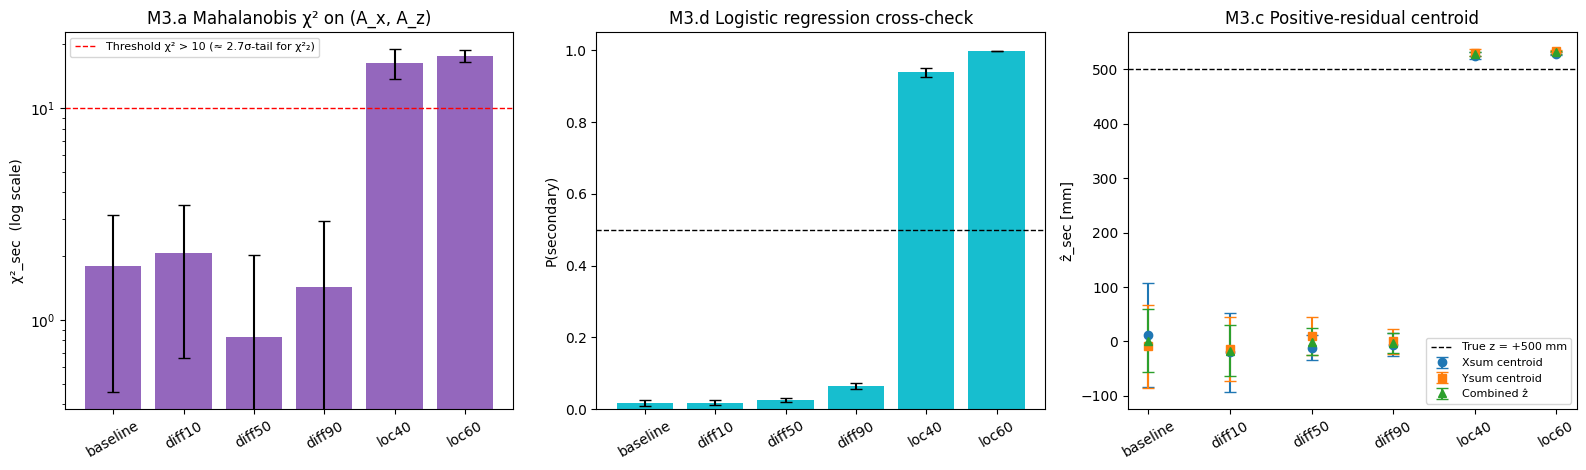

In [7]:
asym_cols = ['A_x', 'A_z']  # exclude A_y: it moves under diffusion (see §4.2 of doc)
baseline_rows = features_df[features_df['case'] == 'baseline']
mu_B = baseline_rows[asym_cols].mean().to_numpy(dtype=float)
Sigma_B = np.cov(baseline_rows[asym_cols].to_numpy(dtype=float).T, ddof=1)
# Guard against singular covariance for tiny baseline spreads:
n_asym = len(asym_cols)
Sigma_B_reg = Sigma_B + 1e-12 * np.eye(n_asym)
Sigma_B_inv = np.linalg.inv(Sigma_B_reg)
print('Mahalanobis test uses asymmetry components:', asym_cols)
print('  (A_y is degenerate with diffusion and is excluded.)')
print('Baseline mean μ_B   =', mu_B)
print('Baseline covariance Σ_B =')
print(pd.DataFrame(Sigma_B, index=asym_cols, columns=asym_cols))

delta_A = features_df[asym_cols].to_numpy(dtype=float) - mu_B[None, :]
chi2_sec = np.einsum('ij,jk,ik->i', delta_A, Sigma_B_inv, delta_A)

# Threshold tuning for χ²₂:
#   P(χ²₂ > 10.0) ≈ 6.7e-3   (≈ 2.7σ-tail)
#   P(χ²₂ > 13.8) ≈ 1.0e-3   (≈ 3.3σ-tail)
#   P(χ²₂ > 25.0) ≈ 3.7e-6   (≈ 4.9σ-tail)
# Empirically on the current campaign:
#   baseline + all diff* cases: χ² ≤ 3
#   loc40 / loc60:              χ² ≈ 16 / 18
# Threshold = 10 sits comfortably between, gives multi-σ rejection of
# secondary, and has expected false-positive rate ≪ 1 per 60 reps.
chi2_threshold = 10.0

m3_df = features_df[['case', 'rep', 'label', 'secondary_present_true',
                     'secondary_fraction_true', 'secondary_z_mm_true',
                     'A_x', 'A_y', 'A_z',
                     'Ysum_positive_residual_per_event',
                     'Xsum_positive_residual_per_event',
                     'Sides_positive_residual_per_event',
                     'Xsum_secondary_roi_rate_per_event',
                     'Ysum_secondary_roi_rate_per_event',
                     'Xsum_positive_residual_centroid_z_mm',
                     'Ysum_positive_residual_centroid_z_mm',
                     'Sides_positive_residual_centroid_z_mm',
                     'Xsum_positive_residual_peak_z_mm',
                     'Ysum_positive_residual_peak_z_mm']].copy()
m3_df['chi2_sec'] = chi2_sec
m3_df['secondary_pred_M3a'] = (chi2_sec > chi2_threshold).astype(int)

# M3.b: residual L1 z-score relative to baseline
baseline_resL1 = baseline_rows['Sides_positive_residual_per_event']
mean_B = float(baseline_resL1.mean())
sd_B = float(baseline_resL1.std(ddof=1)) or 1e-12
m3_df['residual_l1_z'] = (m3_df['Sides_positive_residual_per_event'] - mean_B) / sd_B

# M3.c: combined location estimate
m3_df['zhat_sec_combined_mm'] = np.nanmean(
    m3_df[['Xsum_positive_residual_centroid_z_mm',
           'Ysum_positive_residual_centroid_z_mm']].to_numpy(dtype=float),
    axis=1,
)

# M3.d: logistic regression cross-check (LOO)
log_feature_cols = sorted(set([
    'A_x', 'A_y', 'A_z',
    'Ysum_positive_residual_per_event',
    'Xsum_positive_residual_per_event',
    'Sides_positive_residual_per_event',
    'Xsum_secondary_roi_rate_per_event',
    'Ysum_secondary_roi_rate_per_event',
    'Ysum_residual_l1_per_event',
    'Xsum_residual_l1_per_event',
    'Sides_residual_l1_per_event',
    'Ysum_positive_residual_peak_per_event',
    'Xsum_positive_residual_peak_per_event',
    'Sides_positive_residual_peak_per_event',
    'Ysum_z_std_mm', 'Xsum_z_std_mm', 'Sides_z_std_mm',
    'F_posy',
]))

X_log = features_df[log_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
y_log = features_df['secondary_present_true'].to_numpy(dtype=int)
log_prob = np.zeros(len(features_df))
for tr, te in LeaveOneOut().split(X_log):
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(class_weight='balanced',
                                           C=0.5, max_iter=2000))
    clf.fit(X_log.iloc[tr], y_log[tr])
    log_prob[te] = clf.predict_proba(X_log.iloc[te])[:, 1]

m3_df['secondary_prob_M3d'] = log_prob
m3_df['secondary_pred_M3d'] = (log_prob >= 0.5).astype(int)

print(f'M3.a (Mahalanobis, threshold χ²>{chi2_threshold}):')
print(f'  accuracy   = {accuracy_score(y_log, m3_df["secondary_pred_M3a"]):.3f}')
print('  confusion  =')
display(pd.DataFrame(
    confusion_matrix(y_log, m3_df['secondary_pred_M3a']),
    index=['true_no_sec', 'true_sec'],
    columns=['pred_no_sec', 'pred_sec']
))
print(f'M3.d (Logistic LOO):')
print(f'  accuracy   = {accuracy_score(y_log, m3_df["secondary_pred_M3d"]):.3f}')
print(f'  ROC AUC    = {roc_auc_score(y_log, log_prob):.3f}')

m3_summary = (
    m3_df.groupby('case', sort=False)
    .agg(label=('label', 'first'),
         true_sec=('secondary_present_true', 'first'),
         true_sec_frac=('secondary_fraction_true', 'first'),
         true_sec_z_mm=('secondary_z_mm_true', 'first'),
         chi2_sec_mean=('chi2_sec', 'mean'),
         chi2_sec_sd=('chi2_sec', 'std'),
         M3a_call_fraction=('secondary_pred_M3a', 'mean'),
         residual_l1_z_mean=('residual_l1_z', 'mean'),
         residual_l1_z_sd=('residual_l1_z', 'std'),
         M3d_prob_mean=('secondary_prob_M3d', 'mean'),
         M3d_prob_sd=('secondary_prob_M3d', 'std'),
         M3d_call_fraction=('secondary_pred_M3d', 'mean'),
         zhat_Xsum_mean=('Xsum_positive_residual_centroid_z_mm', 'mean'),
         zhat_Xsum_sd=('Xsum_positive_residual_centroid_z_mm', 'std'),
         zhat_Ysum_mean=('Ysum_positive_residual_centroid_z_mm', 'mean'),
         zhat_Ysum_sd=('Ysum_positive_residual_centroid_z_mm', 'std'),
         zhat_combined_mean=('zhat_sec_combined_mm', 'mean'),
         zhat_combined_sd=('zhat_sec_combined_mm', 'std'))
    .reindex(case_order).reset_index()
)
display(m3_summary)
m3_df.to_csv(metrics_output_dir / 'secondary_per_repetition.csv', index=False)
m3_summary.to_csv(metrics_output_dir / 'secondary_summary.csv', index=False)

# --- Figures ---

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
ax = axes[0]
ax.bar(m3_summary['case'], m3_summary['chi2_sec_mean'],
       yerr=m3_summary['chi2_sec_sd'].fillna(0), capsize=4, color='tab:purple')
ax.axhline(chi2_threshold, color='red', linestyle='--', linewidth=1,
           label=f'Threshold χ² > {chi2_threshold:g} (≈ 2.7σ-tail for χ²₂)')
ax.set_yscale('log')
ax.set_ylabel('χ²_sec  (log scale)')
ax.set_title('M3.a Mahalanobis χ² on (A_x, A_z)')
ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=8)

ax = axes[1]
ax.bar(m3_summary['case'], m3_summary['M3d_prob_mean'],
       yerr=m3_summary['M3d_prob_sd'].fillna(0), capsize=4, color='tab:cyan')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_ylim(0, 1.05); ax.set_ylabel('P(secondary)')
ax.set_title('M3.d Logistic regression cross-check')
ax.tick_params(axis='x', rotation=30)

ax = axes[2]
ax.errorbar(m3_summary['case'], m3_summary['zhat_Xsum_mean'],
            yerr=m3_summary['zhat_Xsum_sd'].fillna(0), fmt='o', capsize=4,
            label='Xsum centroid')
ax.errorbar(m3_summary['case'], m3_summary['zhat_Ysum_mean'],
            yerr=m3_summary['zhat_Ysum_sd'].fillna(0), fmt='s', capsize=4,
            label='Ysum centroid')
ax.errorbar(m3_summary['case'], m3_summary['zhat_combined_mean'],
            yerr=m3_summary['zhat_combined_sd'].fillna(0), fmt='^', capsize=4,
            label='Combined ẑ')
ax.axhline(500, color='black', linestyle='--', linewidth=1, label='True z = +500 mm')
ax.set_ylabel('ẑ_sec [mm]')
ax.set_title('M3.c Positive-residual centroid')
ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'M3_secondary_source_detection_and_location')
plt.show()


## Cross-case validation table

Compact regression-test of the qualitative behaviour expected per the design
document §5. For each metric we report its mean across repetitions per case
in a single table. This is the table to consult when adding new
configurations.


In [8]:
validation_df = (
    features_df.groupby('case', sort=False)
    .agg(F_posy=('F_posy', 'mean'),
         A_y=('A_y', 'mean'),
         A_z=('A_z', 'mean'),
         sigma_z_Ysum=('Ysum_z_std_mm', 'mean'),
         C_posy=('PosY_central_fraction', 'mean'),
         R_tot=('total_rate_per_event', 'mean'))
    .reindex(case_order)
)
validation_df['R_tot_over_baseline'] = validation_df['R_tot'] / baseline_total_rate_mean
validation_df['f_app_posy'] = (
    features_df.groupby('case', sort=False)['posy_central_rate_per_event'].mean()
    .reindex(case_order)
    / baseline_posy_central_rate_mean
)
validation_df['chi2_sec'] = m3_summary.set_index('case')['chi2_sec_mean'].reindex(case_order)
validation_df['delta_Az'] = validation_df['A_z'] - validation_df.loc['baseline', 'A_z']
display(validation_df)
validation_df.to_csv(metrics_output_dir / 'cross_case_validation_table.csv')


,F_posy,A_y,A_z,sigma_z_Ysum,C_posy,R_tot,R_tot_over_baseline,f_app_posy,chi2_sec,delta_Az
case,,,,,,,,,,
baseline,0.474202,0.618453,-0.063460,233.840418,0.567977,1.278984,1.000000,1.000000,1.800000,0.000000
diff10,0.451681,0.570687,0.070071,254.573525,0.545675,1.280268,1.001004,0.912845,2.067209,0.133531
diff50,0.367530,0.351647,-0.025783,326.375475,0.455439,1.306134,1.021228,0.622848,0.831860,0.037677
diff90,0.274036,0.075846,-0.000895,399.513000,0.285713,1.307713,1.022463,0.287395,1.433111,0.062565
loc40,0.387562,0.402366,0.856552,310.091611,0.440827,1.302328,1.018252,0.640093,16.301512,0.920012
loc60,0.345887,0.281826,0.917387,313.623311,0.360115,1.321903,1.033557,0.470779,17.661302,0.980847


## Inference cascade reporter

For every repetition, run the cascade defined in the design document:

```
M3.a  →   if secondary detected: report ẑ_sec
          else:                  report E1/E2 diffusion estimates
M2    →   total amount + applicator-retained amount
```

Output saved as `outputs/Signal_inference_metrics/inference_report.csv`.


In [9]:
report_rows = []
for _, row in features_df.iterrows():
    case_key = row['case']
    rep = int(row['rep'])
    # M3 verdict
    m3_row = m3_df[(m3_df['case'] == case_key) & (m3_df['rep'] == rep)].iloc[0]
    secondary_detected = bool(m3_row['secondary_pred_M3a'])

    # E1 + E2 (only meaningful if no secondary)
    if not secondary_detected:
        e1_preds = e1_predict(row)
        e1_combined = e1_preds['combined']
        e2_pred_val = float(np.clip(e2_model_full.predict(
            row[shape_feature_cols].to_frame().T.fillna(0.0))[0], 0, 100))
    else:
        e1_combined = np.nan
        e2_pred_val = np.nan

    # M2
    R_tot_rel = row['total_rate_per_event'] / baseline_total_rate_mean
    A_hat_uCi = R_tot_rel * reference_activity_uCi
    f_app = row['posy_central_rate_per_event'] / baseline_posy_central_rate_mean

    report_rows.append({
        'case': case_key,
        'rep': rep,
        'M3_secondary_detected': secondary_detected,
        'M3_chi2_sec': float(m3_row['chi2_sec']),
        'M3_zhat_sec_mm': float(m3_row['zhat_sec_combined_mm']) if secondary_detected else np.nan,
        'M1_diffusion_E1_combined': e1_combined,
        'M1_diffusion_E2_ridge': e2_pred_val,
        'M2_R_tot_over_baseline': R_tot_rel,
        'M2_baseline_equivalent_activity_uCi': A_hat_uCi,
        'M2_f_app_posy': f_app,
        'true_diffusion_fraction': row['diffusion_fraction_true'],
        'true_secondary_present': int(row['secondary_present_true']),
        'true_secondary_fraction': row['secondary_fraction_true'],
        'true_secondary_z_mm': row['secondary_z_mm_true'],
    })

report_df = pd.DataFrame(report_rows)
report_df.to_csv(metrics_output_dir / 'inference_report.csv', index=False)

# Per-case mean summary for the conference-style table
report_summary = (
    report_df.groupby('case', sort=False)
    .agg(true_diff=('true_diffusion_fraction', 'first'),
         true_sec=('true_secondary_present', 'first'),
         true_sec_frac=('true_secondary_fraction', 'first'),
         true_sec_z_mm=('true_secondary_z_mm', 'first'),
         M3_call=('M3_secondary_detected', 'mean'),
         M3_chi2=('M3_chi2_sec', 'mean'),
         M3_zhat=('M3_zhat_sec_mm', 'mean'),
         M1_E1=('M1_diffusion_E1_combined', 'mean'),
         M1_E2=('M1_diffusion_E2_ridge', 'mean'),
         M2_A_uCi=('M2_baseline_equivalent_activity_uCi', 'mean'),
         M2_f_app=('M2_f_app_posy', 'mean'))
    .reindex(case_order).reset_index()
)
report_summary.to_csv(metrics_output_dir / 'inference_report_summary.csv', index=False)

print('Per-case inference summary:')
display(report_summary)
print(f'\nReports saved to: {metrics_output_dir / "inference_report.csv"}')
print(f'Figures saved to:  {figure_output_dir}')


Per-case inference summary:


/sessions/laughing-dreamy-goodall/tmp/ipykernel_10/355270052.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  row[shape_feature_cols].to_frame().T.fillna(0.0))[0], 0, 100))
/sessions/laughing-dreamy-goodall/tmp/ipykernel_10/355270052.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  row[shape_feature_cols].to_frame().T.fillna(0.0))[0], 0, 100))
/sessions/laughing-dreamy-goodall/tmp/ipykernel_10/355270052.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.i

,case,true_diff,true_sec,true_sec_frac,true_sec_z_mm,M3_call,M3_chi2,M3_zhat,M1_E1,M1_E2,M2_A_uCi,M2_f_app
0,baseline,0.0,0,0.0,NaN,0.0,1.800000,NaN,0.852109,0.249123,3.000000,1.000000
1,diff10,10.0,0,0.0,NaN,0.0,2.067209,NaN,10.005424,10.014037,3.003012,0.912845
2,diff50,50.0,0,0.0,NaN,0.0,0.831860,NaN,49.959535,49.940890,3.063685,0.622848
3,diff90,90.0,0,0.0,NaN,0.0,1.433111,NaN,89.976245,89.857086,3.067389,0.287395
4,loc40,NaN,1,40.0,500.0,1.0,16.301512,527.745346,NaN,NaN,3.054757,0.640093
5,loc60,NaN,1,60.0,500.0,1.0,17.661302,530.773776,NaN,NaN,3.100672,0.470779



Reports saved to: outputs/Signal_inference_metrics/inference_report.csv
Figures saved to:  docs/figures/Signal_inference_metrics
